Creates P(delta | prev_bass, curr_soprano)

In [1]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

#move to home directory
os.chdir('..')

In [ ]:
def csv_to_tracks(file_path):
    """
    Reads a 4-column CSV and returns four 1D numpy arrays.
    
    Args:
        file_path (str): Path to the .csv file.
        
    Returns:
        tuple: (arr1, arr2, arr3, arr4) as 1D numpy arrays.
    """
    
    # unpack=True turns columns into individual arrays
    # skip_header=1 ignores the first row of text
    # delimiter=',' ensures we parse CSV format correctly
    S, A, T, B = np.genfromtxt(
        file_path, 
        delimiter=',', 
        unpack=True, 
        skip_header=1
    )
    
    return S, A, T, B


# path = Path('jsb_chorales', 'train', 'chorale_000.csv')
# S, A, T, B = csv_to_tracks(path)


In [3]:
def delta_2_index(delta, num_semitones=4):
    """
    turns sometimes negative valued deltas into a consistent index, including processing rests
    [ 0.  1.  2.  3.  4. -4. -3. -2. -1.]
    if non-negative, index is delta
    if negative, index is  2 x (number of semitones) + 1 + delta (e.g. -1 -> 8, -4 -> 5)
    if rest, maps to 2 x (number of semitones) + 1
    arguments: takes in an integer delta (-num_semintones <= delta <= num_semitones) unless it's a rest
    returns: the index
    """

    if num_semitones >= delta >= 0:
        return int(delta)
    elif -1*num_semitones <= delta < 0:
        return int((2*num_semitones+1)+delta)
    else:
        print(f'd2i: delta = {delta}, marking as a rest') #I'm assuming this is unlikely
        return int((2*num_semitones+1))


def index_2_delta(index, num_semitones=4):
    """turns indices back into deltas as described in delta_2_index"""

    if index <= num_semitones: #if delta is positive
        return int(index)
    elif num_semitones < index < 2*num_semitones+1: #if delta is negative 
        return int(index - (2*num_semitones+1))
    else:
        print(f'i2d: index = {index}, marking as a rest')
        return int(100) #placeholder for rest

# num_semitones = 4
# L = np.zeros(num_semitones*2 + 2)
# for i in range(len(L)):
#     L[i] = index_2_delta(i)
    
# print(L)

# for i in range(len(L)):
#     L[i] = delta_2_index(L[i])

# print(L)

In [ ]:
# iterate through a chorale csv
# compute delta from curr_soprano - prev_soprano
# get the previous bass note
# get the current soprano note
# add 1 to the lookup table at index (prev_bass, curr_soprano, delta)
# normalize the lookup table.

# Directory containing the CSV files
train_dir = os.path.join('jsb_chorales', 'train')

def get_delta_3d_lookup(train_dir, num_semitones=4, return_log=True):
    #returns the log probability matrix of P(delta | soprano_{n-1}, bass_n)
    #index by (bass, prev_sporano, delta)
    #lookup_table = np.ones((128, 128, 2*num_semitones+2)) * 1/1000
    lookup_table = np.zeros((128, 128, 2*num_semitones+2))

    # plt.imshow(lookup_table[:, :, 5])

    songs = glob.glob('*.csv', root_dir=train_dir)
    songs = [s for s in songs if not 'd' in s] #remove all strings with 'd' in them (filters out chord csv)

    # Iterate through every .csv in the train directory
    for songname in songs:
        # You can now use `csv_path` for each CSV file
        csv_path = os.path.join(train_dir, songname)
        
        print(f"Processing {csv_path}")
        S, A, T, B = csv_to_tracks(csv_path)
        
        # Combine into array of tuples [(S, A, T, B)]
        SATB_tuples = list(zip(S, A, T, B))
        for i in range(1, len(SATB_tuples)):
            #get current tuple
            s, _, _, b = SATB_tuples[i]

            # get previous soprano note
            prev_s = SATB_tuples[i-1][0]

            # get delta
            delta = s - prev_s

            # add 1 to the lookup table at index (bass, prev_soprano, delta)
            lookup_table[int(b), int(prev_s), delta_2_index(delta, num_semitones=num_semitones)] += 1

        # normalize the lookup table (for each delta)
        for i in range(lookup_table.shape[2]):
            print(i)
            lookup_table[:, :, i] = lookup_table[:, :, i] / np.sum(lookup_table[:, :, i])
            
        if return_log:
            return np.log(lookup_table)
        else:
            return lookup_table

Processing jsb_chorales/train/chorale_198.csv
d2i: delta = 7.0, marking as a rest
d2i: delta = 7.0, marking as a rest
d2i: delta = 5.0, marking as a rest


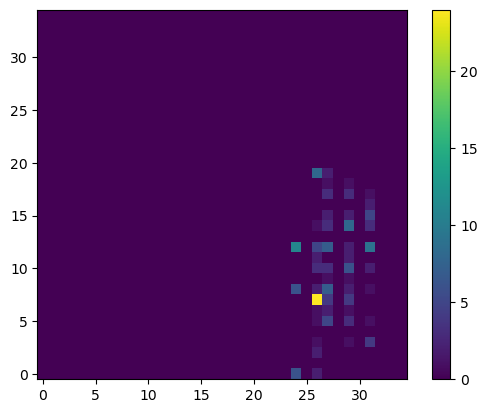

In [98]:
lookup_table = get_delta_3d_lookup(train_dir, num_semitones=2, return_log=False)
plt.imshow(np.sum(lookup_table[42:77, 42:77, :], axis=2), origin='lower')
plt.colorbar()

In [75]:
for i in range(6):
    print(np.sum(lookup_table[:, :, i]))


1.0000000000000002
1.0
0.9999999999999999
1.0
1.0
1.0


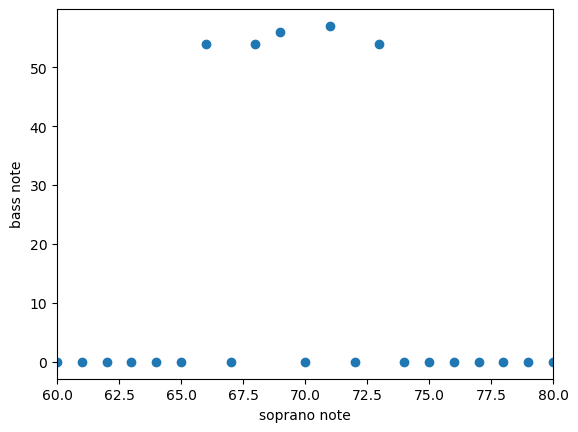

[ 0. 54. 56. 57.]


In [91]:
best_bass = np.zeros(128)
for i in range(128):
    B_est = np.argmax(np.sum(lookup_table[:, i, :], axis=1))
    best_bass[i] = B_est

plt.scatter(np.arange(128), best_bass)
plt.xlabel('soprano note')
plt.ylabel('bass note')
plt.xlim(left=60, right=80)
plt.show()
print(np.unique(best_bass))

In [65]:
print(np.size(lookup_table))
print(np.nonzero(lookup_table))

163840
(array([  0,   0,   0, ..., 127, 127, 127], shape=(65603,)), array([  0,   0,   0, ..., 127, 127, 127], shape=(65603,)), array([3, 4, 5, ..., 4, 5, 6], shape=(65603,)))


In [64]:
lookup_table[0, 0, 0]

np.float64(0.0)